# LISA Traffic Light Detection with YOLOv8
## Complete Workflow: From Dataset Exploration to Model Export

This notebook walks you through the entire process of building a traffic light detector using the LISA dataset and YOLOv8:
1. **Explore** the raw LISA dataset structure and annotations
2. **Convert** Supervisly JSON annotations to YOLO format
3. **Prepare** the dataset with train/val/test splits
4. **Train** a YOLOv8 object detection model
5. **Evaluate** the model on validation and test sets
6. **Infer** predictions on sample images
7. **Export** the model to ONNX format for deployment

The dataset is pre-split into `Dataset/train/` and `Dataset/test/`. We'll create a validation split from train.

In [1]:
pip install numpy matplotlib pillow ultralytics


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [34]:
# 1. SETUP AND IMPORTS
import os
import sys
import json
import shutil
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)

# Project paths
PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "Dataset"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
RUNS_DIR = PROJECT_ROOT / "runs"

print(f"Project Root: {PROJECT_ROOT}")
print(f"Dataset Dir: {DATASET_DIR}")
print(f"Processed Data Dir: {DATA_PROCESSED_DIR}")

# # Create output directories if they don't exist
# DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
# MODELS_DIR.mkdir(parents=True, exist_ok=True)
# RUNS_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Directories ready")

Project Root: /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project
Dataset Dir: /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/Dataset
Processed Data Dir: /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/data/processed
✓ Directories ready


## Step 1: Explore the LISA Dataset Structure

Let's first understand what we're working with:
- Dataset is organized in `Dataset/train/` and `Dataset/test/`
- Each split has `img/` (images) and `ann/` (Supervisly JSON annotations)
- Annotations contain bounding boxes with class labels

In [ ]:
# 2. EXPLORE DATASET STRUCTURE
print("DATASET STRUCTURE")

# Check meta.json
with open(DATASET_DIR / "meta.json") as f:
    meta = json.load(f)

print(f"\nClasses in Dataset ({len(meta['classes'])} total):")
CLASS_NAMES = []
for idx, cls in enumerate(meta['classes']):
    CLASS_NAMES.append(cls['title'])
    print(f"  {idx}: {cls['title']}")

CLASS_MAP = {name: idx for idx, name in enumerate(CLASS_NAMES)}
print(f"\n✓ Total classes: {len(CLASS_NAMES)}")

# Explore train split
train_img_dir = DATASET_DIR / "train" / "img"
train_ann_dir = DATASET_DIR / "train" / "ann"
train_images = sorted([f for f in os.listdir(train_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
train_anns = sorted([f for f in os.listdir(train_ann_dir) if f.endswith('.json')])

print(f"\nTrain Split:")
print(f"  Images: {len(train_images)}")
print(f"  Annotations: {len(train_anns)}")
print(f"  Sample images: {train_images[:3]}")

# Explore test split
test_img_dir = DATASET_DIR / "test" / "img"
test_ann_dir = DATASET_DIR / "test" / "ann"
test_images = sorted([f for f in os.listdir(test_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
test_anns = sorted([f for f in os.listdir(test_ann_dir) if f.endswith('.json')])

print(f"\nTest Split:")
print(f"  Images: {len(test_images)}")
print(f"  Annotations: {len(test_anns)}")
print(f"  Sample images: {test_images[:3]}")

print(f"\nTotal images across all splits: {len(train_images) + len(test_images)}")

DATASET STRUCTURE

Classes in Dataset (14 total):
  0: go
  1: go forward
  2: go forward traffic light
  3: go left
  4: go left traffic light
  5: go traffic light
  6: stop
  7: stop left
  8: stop left traffic light
  9: stop traffic light
  10: warning
  11: warning left
  12: warning left traffic light
  13: warning traffic light

✓ Total classes: 14

Train Split:
  Images: 20535
  Annotations: 20535
  Sample images: ['dayClip1--00000.jpg', 'dayClip1--00001.jpg', 'dayClip1--00002.jpg']

Test Split:
  Images: 22481
  Annotations: 22481
  Sample images: ['daySequence1--00000.jpg', 'daySequence1--00001.jpg', 'daySequence1--00002.jpg']

Total images across all splits: 43016


## Step 2: Understand the Annotation Format

Let's examine a few annotation files to understand the JSON structure.

In [36]:
# 3. EXAMINE ANNOTATION FORMAT
print("="*60)
print("ANNOTATION FORMAT EXAMPLE")
print("="*60)

# Load one annotation to understand structure
sample_ann_file = train_ann_dir / train_anns[0]
with open(sample_ann_file) as f:
    sample_ann = json.load(f)

print(f"\nAnnotation file: {train_anns[0]}")
print(f"Image dimensions: {sample_ann['size']['width']} x {sample_ann['size']['height']}")
print(f"Number of objects: {len(sample_ann.get('objects', []))}")

print("\nFirst object structure:")
if sample_ann.get('objects'):
    obj = sample_ann['objects'][0]
    print(f"  classTitle: {obj['classTitle']}")
    print(f"  geometryType: {obj['geometryType']}")
    print(f"  points.exterior: {obj['points']['exterior']}")  # [[x1,y1], [x2,y2]]
    print(f"  points format: [[top-left], [bottom-right]]")

# Show all classes in this annotation
print("\nAll classes in this image:")
for obj in sample_ann.get('objects', []):
    print(f"  - {obj['classTitle']}")

ANNOTATION FORMAT EXAMPLE

Annotation file: dayClip1--00000.jpg.json
Image dimensions: 1280 x 960
Number of objects: 4

First object structure:
  classTitle: go traffic light
  geometryType: rectangle
  points.exterior: [[698, 333], [710, 358]]
  points format: [[top-left], [bottom-right]]

All classes in this image:
  - go traffic light
  - go traffic light
  - go
  - go


## Step 3: Visualize an Annotation

Let's load an image and its annotations, then visualize the bounding boxes.

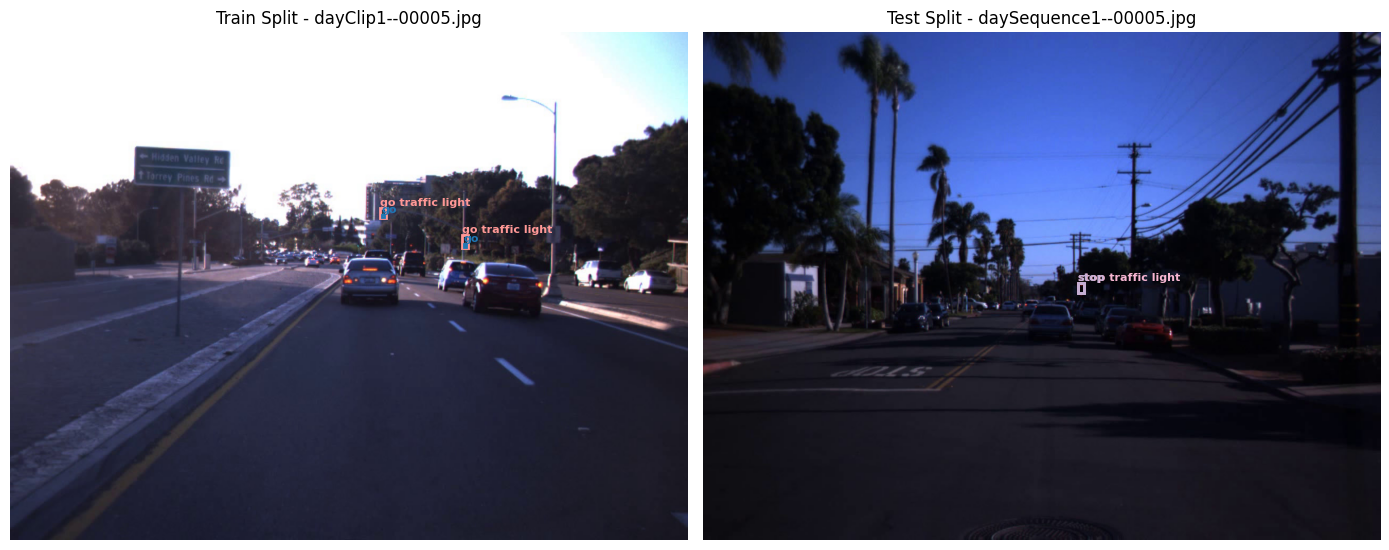

✓ Visualized sample annotations from train and test splits


In [37]:
# 4. VISUALIZE ANNOTATION
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (split_name, img_dir, ann_dir, anns) in enumerate([
    ("Train", train_img_dir, train_ann_dir, train_anns),
    ("Test", test_img_dir, test_ann_dir, test_anns)
]):
    # Load image and annotation
    ann_file = ann_dir / anns[5]  # Pick 5th image for variety
    img_name = str(ann_file.name).replace('.json', '')
    img_path = img_dir / img_name
    
    img = Image.open(img_path)
    with open(ann_file) as f:
        ann = json.load(f)
    
    ax = axes[idx]
    ax.imshow(img)
    ax.set_title(f"{split_name} Split - {img_name}")
    ax.axis('off')
    
    # Draw bounding boxes
    colors = plt.cm.get_cmap('tab20')(np.linspace(0, 1, len(CLASS_NAMES)))
    color_map = {name: colors[i] for i, name in enumerate(CLASS_NAMES)}
    
    for obj in ann.get('objects', []):
        pts = obj['points']['exterior']
        x1, y1 = pts[0]
        x2, y2 = pts[1]
        x_min = min(x1, x2)
        y_min = min(y1, y2)
        width = abs(x2 - x1)
        height = abs(y2 - y1)
        
        class_title = obj['classTitle']
        color = color_map[class_title]
        
        rect = Rectangle((x_min, y_min), width, height, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x_min, y_min - 5, class_title, fontsize=8, color=color, weight='bold')

plt.tight_layout()
plt.show()

print("✓ Visualized sample annotations from train and test splits")

## Step 4: Convert LISA Annotations to YOLO Format

YOLO expects:
- For each image: a corresponding `.txt` file with one line per object
- Format: `class_id x_center y_center width height`
- All coordinates normalized to [0, 1]

We'll convert the Supervisly JSON format to YOLO format.

In [38]:
# 5. CONVERT LISA ANNOTATIONS TO YOLO FORMAT
print("="*60)
print("CONVERTING ANNOTATIONS TO YOLO FORMAT")
print("="*60)

def convert_annotation_to_yolo(ann_data, class_map):
    """Convert Supervisly annotation to YOLO format"""
    img_h = ann_data["size"]["height"]
    img_w = ann_data["size"]["width"]
    
    yolo_lines = []
    for obj in ann_data.get("objects", []):
        class_title = obj.get("classTitle", "").strip()
        if not class_title or class_title not in class_map:
            continue
        
        pts = obj["points"]["exterior"]
        if len(pts) != 2:
            continue
        
        x1, y1 = pts[0]
        x2, y2 = pts[1]
        
        x_min = min(x1, x2)
        x_max = max(x1, x2)
        y_min = min(y1, y2)
        y_max = max(y1, y2)
        
        # Normalize to [0, 1]
        x_center = ((x_min + x_max) / 2.0) / img_w
        y_center = ((y_min + y_max) / 2.0) / img_h
        width = (x_max - x_min) / img_w
        height = (y_max - y_min) / img_h
        
        # Clamp to [0, 1]
        x_center = max(0, min(1, x_center))
        y_center = max(0, min(1, y_center))
        width = max(0, min(1, width))
        height = max(0, min(1, height))
        
        class_id = class_map[class_title]
        yolo_line = f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"
        yolo_lines.append(yolo_line)
    
    return yolo_lines

def process_split(split_name, img_dir, ann_dir, out_img_dir, out_lbl_dir, class_map, use_symlink=True):
    """Process one split (train/test) and convert to YOLO format"""
    print(f"\nProcessing {split_name} split...")
    
    ann_files = sorted([f for f in os.listdir(ann_dir) if f.endswith(".json")])
    processed = 0
    
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)
    
    for ann_file in ann_files:
        ann_path = os.path.join(ann_dir, ann_file)
        img_name = ann_file.replace(".json", "")  # e.g., "image.jpg"
        img_path = os.path.join(img_dir, img_name)
        
        if not os.path.exists(img_path):
            continue
        
        # Convert annotation
        with open(ann_path) as f:
            ann_data = json.load(f)
        yolo_lines = convert_annotation_to_yolo(ann_data, class_map)
        
        # Create symlink or copy for image
        out_img_path = os.path.join(out_img_dir, img_name)
        if not os.path.exists(out_img_path):
            if use_symlink:
                os.symlink(os.path.abspath(img_path), out_img_path)
            else:
                shutil.copy2(img_path, out_img_path)
        
        # Write YOLO label file
        lbl_name = img_name + ".txt"
        out_lbl_path = os.path.join(out_lbl_dir, lbl_name)
        with open(out_lbl_path, "w") as f:
            f.write("\n".join(yolo_lines))
            if yolo_lines:
                f.write("\n")
        
        processed += 1
    
    print(f"  ✓ Processed {processed} images from {split_name}")
    return processed

# Process train split
train_processed = process_split(
    "Train",
    img_dir=str(train_img_dir),
    ann_dir=str(train_ann_dir),
    out_img_dir=str(DATA_PROCESSED_DIR / "images" / "train"),
    out_lbl_dir=str(DATA_PROCESSED_DIR / "labels" / "train"),
    class_map=CLASS_MAP,
    use_symlink=True
)

# Process test split
test_processed = process_split(
    "Test",
    img_dir=str(test_img_dir),
    ann_dir=str(test_ann_dir),
    out_img_dir=str(DATA_PROCESSED_DIR / "images" / "test"),
    out_lbl_dir=str(DATA_PROCESSED_DIR / "labels" / "test"),
    class_map=CLASS_MAP,
    use_symlink=True
)

print(f"\n✓ Total: {train_processed + test_processed} images converted")

CONVERTING ANNOTATIONS TO YOLO FORMAT

Processing Train split...
  ✓ Processed 20535 images from Train

Processing Test split...
  ✓ Processed 22481 images from Test

✓ Total: 43016 images converted


## Step 5: Create Validation Split from Train

We'll sample 10% of training images to create a validation split for model tuning.

In [39]:
# 6. CREATE VALIDATION SPLIT (10% from train)
print("="*60)
print("CREATING VALIDATION SPLIT")
print("="*60)

train_img_dir = DATA_PROCESSED_DIR / "images" / "train"
train_lbl_dir = DATA_PROCESSED_DIR / "labels" / "train"
val_img_dir = DATA_PROCESSED_DIR / "images" / "val"
val_lbl_dir = DATA_PROCESSED_DIR / "labels" / "val"

os.makedirs(val_img_dir, exist_ok=True)
os.makedirs(val_lbl_dir, exist_ok=True)

# Get all train images
train_images_list = sorted([f for f in os.listdir(train_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
n_val = max(1, int(len(train_images_list) * 0.1))
val_images = set(random.sample(train_images_list, n_val))

print(f"\nTotal train images: {len(train_images_list)}")
print(f"Moving to val split: {len(val_images)} ({100*len(val_images)/len(train_images_list):.1f}%)")

# Move images and labels to val
for img_name in val_images:
    # Move image
    src_img = train_img_dir / img_name
    dst_img = val_img_dir / img_name
    if src_img.exists():
        # If symlink, recreate it in val; if file, move it
        if os.path.islink(src_img):
            target = os.readlink(src_img)
            if dst_img.exists() or dst_img.is_symlink():
                dst_img.unlink()
            os.symlink(target, dst_img)
            os.remove(src_img)
        else:
            shutil.move(str(src_img), str(dst_img))
    
    # Move label
    lbl_name = img_name + ".txt"
    src_lbl = train_lbl_dir / lbl_name
    dst_lbl = val_lbl_dir / lbl_name
    if src_lbl.exists():
        shutil.move(str(src_lbl), str(dst_lbl))

# Verify splits
train_count = len([f for f in os.listdir(train_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
val_count = len([f for f in os.listdir(val_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
test_count = len([f for f in os.listdir(DATA_PROCESSED_DIR / "images" / "test") if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

print(f"\nFinal split:")
print(f"  Train: {train_count} images")
print(f"  Val:   {val_count} images")
print(f"  Test:  {test_count} images")
print(f"  Total: {train_count + val_count + test_count} images")

CREATING VALIDATION SPLIT

Total train images: 20535
Moving to val split: 2053 (10.0%)

Final split:
  Train: 18482 images
  Val:   3916 images
  Test:  22481 images
  Total: 44879 images


## Step 6: Create YOLOv8 Configuration File (data.yaml)

YOLOv8 needs a YAML file pointing to the dataset location and class names.

In [40]:
# 7. CREATE DATA.YAML FOR YOLOV8
print("="*60)
print("CREATING YOLOv8 CONFIGURATION (data.yaml)")
print("="*60)

yaml_content = """path: data/processed
train: images/train
val: images/val
test: images/test

nc: {nc}
names:
{names_list}
""".format(
    nc=len(CLASS_NAMES),
    names_list="\n".join([f"  {idx}: {name}" for idx, name in enumerate(CLASS_NAMES)])
)

yaml_path = DATA_PROCESSED_DIR / "data.yaml"
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"\nCreated: {yaml_path}")
print(f"Classes: {len(CLASS_NAMES)}")
print("\nContent:")
print(yaml_content)

CREATING YOLOv8 CONFIGURATION (data.yaml)

Created: /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/data/processed/data.yaml
Classes: 14

Content:
path: data/processed
train: images/train
val: images/val
test: images/test

nc: 14
names:
  0: go
  1: go forward
  2: go forward traffic light
  3: go left
  4: go left traffic light
  5: go traffic light
  6: stop
  7: stop left
  8: stop left traffic light
  9: stop traffic light
  10: warning
  11: warning left
  12: warning left traffic light
  13: warning traffic light



## Step 7b: Filter the Dataset to Detectable Classes

The previous training runs failed (all losses stayed at 0) because the dataset mixes two kinds of objects:
- **Traffic light housings** (the lamp boxes) — ~6×13 px at imgsz=640 — small but detectable.
- **Individual bulbs** (`go`, `stop`, `warning`, etc.) — ~2×3 px at imgsz=640 — **smaller than YOLOv8's minimum detector stride**, so the model literally cannot learn them.

The bulb labels were poisoning training. The cell below rewrites every label file in `data/processed/labels/{train,val,test}/`, keeping only the 7 housing classes and renumbering them 0–6. It also updates `data.yaml` to declare 7 classes instead of 14.

Run this once, then re-run the training cell below.

In [41]:
# 7b. FILTER DATASET TO 7 HOUSING CLASSES
# The bulb classes (go, stop, warning, etc.) are only 2-3 px wide at imgsz=640
# and YOLOv8 cannot learn objects smaller than its detector stride (~8 px).
# Earlier training runs collapsed (all losses = 0) because of this.
# We keep only the 7 "* traffic light" housing classes and renumber them 0-6.
print("="*60)
print("FILTERING DATASET TO 7 HOUSING CLASSES")
print("="*60)

KEEP_NAMES = [n for n in CLASS_NAMES if n.endswith("traffic light")]
OLD_TO_NEW = {CLASS_NAMES.index(n): new_id for new_id, n in enumerate(KEEP_NAMES)}

print(f"\nKeeping {len(KEEP_NAMES)} classes:")
for new_id, name in enumerate(KEEP_NAMES):
    print(f"  old id {CLASS_NAMES.index(name):2d}  ->  new id {new_id}:  {name}")

total = kept = empty_after = 0
for split in ["train", "val", "test"]:
    lbl_dir = DATA_PROCESSED_DIR / "labels" / split
    if not lbl_dir.exists():
        continue
    files = list(lbl_dir.glob("*.txt"))
    for f in files:
        new_lines = []
        for line in f.read_text().splitlines():
            parts = line.strip().split()
            if not parts:
                continue
            total += 1
            old_id = int(parts[0])
            if old_id in OLD_TO_NEW:
                new_lines.append(f"{OLD_TO_NEW[old_id]} " + " ".join(parts[1:]))
                kept += 1
        f.write_text(("\n".join(new_lines) + "\n") if new_lines else "")
        if not new_lines:
            empty_after += 1
    print(f"  {split}: rewrote {len(files)} label files")

print(f"\nKept {kept}/{total} annotations ({100*kept/total:.1f}%)")
print(f"Images with no housings (now empty .txt = background): {empty_after}")

# Rewrite data.yaml for 7 classes
yaml_content = (
    "path: data/processed\n"
    "train: images/train\n"
    "val: images/val\n"
    "test: images/test\n\n"
    f"nc: {len(KEEP_NAMES)}\n"
    "names:\n"
    + "\n".join(f"  {i}: {n}" for i, n in enumerate(KEEP_NAMES)) + "\n"
)
(DATA_PROCESSED_DIR / "data.yaml").write_text(yaml_content)
print(f"\n✓ data.yaml updated to {len(KEEP_NAMES)} classes:\n{yaml_content}")


FILTERING DATASET TO 7 HOUSING CLASSES

Keeping 7 classes:
  old id  2  ->  new id 0:  go forward traffic light
  old id  4  ->  new id 1:  go left traffic light
  old id  5  ->  new id 2:  go traffic light
  old id  8  ->  new id 3:  stop left traffic light
  old id  9  ->  new id 4:  stop traffic light
  old id 12  ->  new id 5:  warning left traffic light
  old id 13  ->  new id 6:  warning traffic light
  train: rewrote 18482 label files
  val: rewrote 3916 label files
  test: rewrote 22481 label files

Kept 109495/223526 annotations (49.0%)
Images with no housings (now empty .txt = background): 8603

✓ data.yaml updated to 7 classes:
path: data/processed
train: images/train
val: images/val
test: images/test

nc: 7
names:
  0: go forward traffic light
  1: go left traffic light
  2: go traffic light
  3: stop left traffic light
  4: stop traffic light
  5: warning left traffic light
  6: warning traffic light



## Step 7: Verify Prepared Dataset

Let's verify the dataset is correctly prepared by checking a few YOLO labels and visualizing them.

In [42]:
# 8. VERIFY PREPARED DATASET
print("="*60)
print("VERIFYING PREPARED DATASET")
print("="*60)

# Check a few YOLO label files
sample_lbl_files = sorted(os.listdir(DATA_PROCESSED_DIR / "labels" / "train"))[:3]

print("\nSample YOLO label files:")
for lbl_file in sample_lbl_files:
    lbl_path = DATA_PROCESSED_DIR / "labels" / "train" / lbl_file
    with open(lbl_path) as f:
        content = f.read()
    print(f"\n{lbl_file}:")
    if content.strip():
        for line in content.strip().split('\n'):
            parts = line.split()
            class_id = int(parts[0])
            class_name = CLASS_NAMES[class_id]
            print(f"  {class_name}: {line}")
    else:
        print("  (no objects)")

print("\n✓ Dataset verification complete")

VERIFYING PREPARED DATASET

Sample YOLO label files:

dayClip1--00000.jpg.txt:
  go forward traffic light: 2 0.550000 0.359896 0.009375 0.026042
  go forward traffic light: 2 0.665625 0.417708 0.009375 0.020833

dayClip1--00001.jpg.txt:
  go forward traffic light: 2 0.550000 0.361458 0.009375 0.020833
  go forward traffic light: 2 0.666406 0.416667 0.009375 0.020833

dayClip1--00002.jpg.txt:
  go forward traffic light: 2 0.550000 0.357812 0.009375 0.026042
  go forward traffic light: 2 0.667188 0.415625 0.009375 0.020833

✓ Dataset verification complete


## Step 8: Install YOLOv8 and Dependencies

In [45]:
# 9. INSTALL YOLOV8
import subprocess
import sys

print("="*60)
print("INSTALLING YOLOV8 AND DEPENDENCIES")
print("="*60)

packages = ['ultralytics']

for package in packages:
    try:
        __import__(package.replace('-', '_'))
        print(f"✓ {package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✓ {package} installed")

print("\n✓ All dependencies ready")

INSTALLING YOLOV8 AND DEPENDENCIES
✓ ultralytics already installed

✓ All dependencies ready


## Step 9: Train YOLOv8 Model

Now we'll train a YOLOv8 object detection model on the prepared dataset.

In [ ]:
# 10. TRAIN YOLOV8 MODEL
from ultralytics import YOLO

print("="*60)
print("TRAINING YOLOV8 MODEL")
print("="*60)

# Clear stale YOLO label caches so labels are re-parsed fresh after
# any change to the .txt files (e.g. the 7b filter step).
for split in ("train", "val"):
    p = DATA_PROCESSED_DIR / "labels" / f"{split}.cache"
    if p.exists():
        p.unlink()
        print(f"  removed stale cache: {p}")

# Nano model — small/fast. Bump to yolov8s.pt for higher accuracy.
model = YOLO('yolov8n.pt')

# Notes on this config:
#   imgsz=1280  source images are 1280x960; this keeps housings ~12-26 px.
#   epochs=50   10 was nowhere near enough.
#   batch=8     larger imgsz uses more GPU memory; drop to 4 if you OOM.
#   amp=False   REQUIRED on this machine. With amp=True under
#               ultralytics 8.4.43 + torch 2.12-nightly + RTX 5090 (sm_120),
#               the box-regression pathway silently produces NaNs under
#               autocast. The grad scaler skips every batch, weights never
#               update, and box_loss / dfl_loss stay at 0 for every epoch
#               (this is what killed v1 and v2). The torch 2.11 + py3.12
#               venv is fine with AMP, but disabling it costs little and
#               keeps the cell robust across the two interpreters in this
#               repo.
results = model.train(
    data=str(DATA_PROCESSED_DIR / 'data.yaml'),
    epochs=50,
    imgsz=1280,
    batch=8,
    patience=10,
    device=0,                       # 'cpu' if no GPU; will be VERY slow on CPU at imgsz=1280
    amp=False,
    project=str(RUNS_DIR),
    name='traffic_light_v3',
)

print("\n✓ Training complete")
print(f"Results saved to: {RUNS_DIR}/traffic_light_v3")
print("Sanity check: open results.csv and confirm train/box_loss is")
print("DECREASING over epochs (not stuck at 0). If it's 0, AMP slipped back on.")


## Step 10: Run Inference on Sample Images

Let's use the trained model to detect traffic lights in sample images.

In [47]:
# 11. RUN INFERENCE ON SAMPLE IMAGES
print("="*60)
print("INFERENCE ON SAMPLE IMAGES")
print("="*60)

# Load best model
best_model_path = list(RUNS_DIR.glob("**/weights/best.pt"))[0] if list(RUNS_DIR.glob("**/weights/best.pt")) else None

if best_model_path:
    model = YOLO(str(best_model_path))
    
    # Run inference on test images
    test_img_dir = DATA_PROCESSED_DIR / "images" / "test"
    test_images = sorted([f for f in os.listdir(test_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])[:5]
    
    print(f"\nRunning inference on {len(test_images)} test images...")
    
    results = model.predict(
        source=[str(test_img_dir / img) for img in test_images],
        save=True,
        conf=0.5,
        project=str(RUNS_DIR),
        name='test_predictions'
    )
    
    print(f"\n✓ Predictions saved")
else:
    print("No trained model found.")

INFERENCE ON SAMPLE IMAGES

Running inference on 5 test images...

0: 480x640 (no detections), 0.5ms
1: 480x640 (no detections), 0.5ms
2: 480x640 (no detections), 0.5ms
3: 480x640 (no detections), 0.5ms
4: 480x640 (no detections), 0.5ms
Speed: 0.7ms preprocess, 0.5ms inference, 0.1ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/runs/test_predictions-3

✓ Predictions saved


## Step 11.5: Evaluation — TP / FP / FN and Detection Metrics

Two complementary views of model quality on the held-out **test** split:

1. **`model.val(...)`** — the standard ultralytics evaluation. Sweeps thresholds and reports Precision, Recall, mAP@0.5, mAP@0.5:0.95 (overall and per-class), and writes a confusion matrix + PR curves to disk.

2. **Manual TP / FP / FN at a fixed operating point** — what you actually care about for deployment: "at conf ≥ 0.25 and IoU ≥ 0.5, how many lights of each class do we catch (TP), miss (FN), or hallucinate (FP)?"

> **Why no "True Negative" column?** In object detection TN is not well-defined — every patch of background with no prediction is technically a true negative, but there is no bounded count of those. The accepted substitutes are **Precision**, **Recall**, **F1**, and a Jaccard-style accuracy = `TP / (TP + FP + FN)`.

Run the two cells below in order.


In [ ]:
# 15. STANDARD YOLO EVALUATION ON TEST SET
# Runs ultralytics' built-in val() on the test split. Produces overall +
# per-class Precision / Recall / mAP50 / mAP50-95, and also writes plots and
# a confusion matrix to disk under runs/test_eval/.

from ultralytics import YOLO
from pathlib import Path
import pandas as pd

# Auto-pick the most recently trained best.pt
best = sorted(Path("runs").glob("**/weights/best.pt"), key=lambda p: p.stat().st_mtime)[-1]
print(f"Evaluating model: {best}\n")
model = YOLO(str(best))

metrics = model.val(
    data=str(DATA_PROCESSED_DIR / "data.yaml"),
    split="test",
    imgsz=1280,
    conf=0.001,        # low conf -> PR curve is sampled across all thresholds
    iou=0.6,           # NMS IoU
    project=str(RUNS_DIR),
    name="test_eval",
    exist_ok=True,
    plots=True,
    verbose=False,
)

print("="*60)
print("OVERALL TEST METRICS")
print("="*60)
print(f"Precision (mean):  {metrics.box.mp:.4f}")
print(f"Recall    (mean):  {metrics.box.mr:.4f}")
print(f"mAP@0.5:           {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95:      {metrics.box.map:.4f}")

print("\n" + "="*60)
print("PER-CLASS METRICS")
print("="*60)
names = model.names
rows = []
for i, ci in enumerate(metrics.box.ap_class_index):
    rows.append({
        "class":    names[int(ci)],
        "P":        round(float(metrics.box.p[i]), 4),
        "R":        round(float(metrics.box.r[i]), 4),
        "mAP50":    round(float(metrics.box.ap50[i]), 4),
        "mAP50-95": round(float(metrics.box.ap[i].mean()), 4),
    })
print(pd.DataFrame(rows).to_string(index=False))

print(f"\nPlots + confusion matrix saved to: {metrics.save_dir}")


In [ ]:
# 16. MANUAL TP / FP / FN BREAKDOWN ON TEST SET
# Per-image IoU matching to compute per-class TP, FP, FN, Precision, Recall,
# F1 at ONE chosen (conf, IoU) operating point — the threshold you would
# actually deploy with. The YOLO val() cell above optimizes across thresholds;
# this answers: "at conf>=X and IoU>=Y, how many lights do we actually catch?"
#
# Note on "True Negative" in detection: TN is not well-defined because every
# image region with no object is technically a TN, and that count is unbounded.
# Standard substitutes: Precision, Recall, F1, and a Jaccard-style accuracy
# computed as TP / (TP + FP + FN).

import numpy as np, pandas as pd
from pathlib import Path
from collections import defaultdict
from ultralytics import YOLO

# ----- tune these for your operating point -----
IOU_THRESH  = 0.5
CONF_THRESH = 0.25
EVAL_LIMIT  = 3000      # None to evaluate ALL ~22k test images (slower)
BATCH       = 16
# -----------------------------------------------

best = sorted(Path("runs").glob("**/weights/best.pt"), key=lambda p: p.stat().st_mtime)[-1]
print(f"Model: {best}")
model = YOLO(str(best))
names = model.names

IMG_DIR = DATA_PROCESSED_DIR / "images" / "test"
LBL_DIR = DATA_PROCESSED_DIR / "labels" / "test"
img_files = sorted(IMG_DIR.glob("*.jpg"))
if EVAL_LIMIT and len(img_files) > EVAL_LIMIT:
    rng = np.random.default_rng(0)
    img_files = list(rng.choice(img_files, size=EVAL_LIMIT, replace=False))

print(f"Scoring {len(img_files)} images @ conf>={CONF_THRESH}, IoU>={IOU_THRESH}\n")

def yolo_to_xyxy(b, W, H):
    cx, cy, w, h = b
    return [(cx-w/2)*W, (cy-h/2)*H, (cx+w/2)*W, (cy+h/2)*H]

def iou(a, b):
    x1, y1 = max(a[0], b[0]), max(a[1], b[1])
    x2, y2 = min(a[2], b[2]), min(a[3], b[3])
    iw, ih = max(0.0, x2-x1), max(0.0, y2-y1)
    inter = iw * ih
    union = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter / union if union > 0 else 0.0

tp = defaultdict(int); fp = defaultdict(int); fn = defaultdict(int)

for i in range(0, len(img_files), BATCH):
    batch = img_files[i:i+BATCH]
    results = model.predict([str(p) for p in batch], conf=CONF_THRESH,
                            imgsz=1280, verbose=False)
    for img_path, r in zip(batch, results):
        H, W = r.orig_shape
        # ground truth
        lbl = LBL_DIR / (img_path.stem + ".txt")
        gts = []
        if lbl.exists():
            for line in lbl.read_text().splitlines():
                parts = line.split()
                if len(parts) != 5: continue
                gts.append((int(parts[0]), yolo_to_xyxy([float(x) for x in parts[1:]], W, H)))
        # predictions, highest-confidence first
        preds = []
        if r.boxes is not None and len(r.boxes) > 0:
            xy = r.boxes.xyxy.cpu().numpy()
            cl = r.boxes.cls.cpu().numpy().astype(int)
            cf = r.boxes.conf.cpu().numpy()
            order = cf.argsort()[::-1]
            preds = [(int(cl[k]), xy[k].tolist()) for k in order]
        # greedy IoU + same-class matching
        used = [False] * len(gts)
        for pc, pb in preds:
            best_j, best_iou = -1, 0.0
            for j, (gc, gb) in enumerate(gts):
                if used[j] or gc != pc: continue
                ov = iou(pb, gb)
                if ov > best_iou:
                    best_iou, best_j = ov, j
            if best_j >= 0 and best_iou >= IOU_THRESH:
                tp[pc] += 1
                used[best_j] = True
            else:
                fp[pc] += 1
        for j, (gc, _) in enumerate(gts):
            if not used[j]:
                fn[gc] += 1
    if (i // BATCH) % 20 == 0:
        print(f"  processed {i + len(batch):>5}/{len(img_files)}")

rows, all_tp, all_fp, all_fn = [], 0, 0, 0
for cid, cname in names.items():
    t, f_, n = tp[cid], fp[cid], fn[cid]
    P  = t / (t + f_) if (t + f_) else 0.0
    R  = t / (t + n)  if (t + n)  else 0.0
    F1 = 2*P*R / (P + R) if (P + R) else 0.0
    A  = t / (t + f_ + n) if (t + f_ + n) else 0.0
    rows.append({"class": cname, "GT": t + n, "TP": t, "FP": f_, "FN": n,
                 "Precision": round(P, 3), "Recall": round(R, 3),
                 "F1": round(F1, 3), "Accuracy": round(A, 3)})
    all_tp += t; all_fp += f_; all_fn += n

P  = all_tp / (all_tp + all_fp) if (all_tp + all_fp) else 0
R  = all_tp / (all_tp + all_fn) if (all_tp + all_fn) else 0
F1 = 2*P*R / (P + R) if (P + R) else 0
A  = all_tp / (all_tp + all_fp + all_fn) if (all_tp + all_fp + all_fn) else 0
rows.append({"class": "ALL (micro)", "GT": all_tp + all_fn,
             "TP": all_tp, "FP": all_fp, "FN": all_fn,
             "Precision": round(P, 3), "Recall": round(R, 3),
             "F1": round(F1, 3), "Accuracy": round(A, 3)})

print("\n" + "="*72)
print(f"PER-CLASS TP / FP / FN  @ conf={CONF_THRESH}, IoU={IOU_THRESH}")
print("="*72)
print(pd.DataFrame(rows).to_string(index=False))


## Step 11: Export Model to ONNX

Export the trained model to ONNX format for deployment and portability.

In [48]:
# 12. EXPORT MODEL TO ONNX
print("="*60)
print("EXPORTING MODEL TO ONNX")
print("="*60)

best_model_path = list(RUNS_DIR.glob("**/weights/best.pt"))[0] if list(RUNS_DIR.glob("**/weights/best.pt")) else None

if best_model_path:
    model = YOLO(str(best_model_path))
    
    print(f"\nExporting model to ONNX format...")
    model.export(format='onnx', imgsz=640)
    
    # Copy the best .pt model to models directory
    pt_path = MODELS_DIR / "traffic_light_detector.pt"
    shutil.copy2(str(best_model_path), str(pt_path))
    print(f"✓ Copied best model to: {pt_path}")
    print(f"✓ ONNX export completed")
else:
    print("No trained model found.")

EXPORTING MODEL TO ONNX

Exporting model to ONNX format...
Ultralytics 8.4.45 🚀 Python-3.12.3 torch-2.11.0+cu130 CPU (Intel Core i9-14900K)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,008,378 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/runs/traffic_light_v1-2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 18, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Resolved 12 packages in 2.00s
 Downloaded ml-dtypes
 Downloaded onnx
 Downloaded onnxruntime-gpu
Prepared 7 packages in 1m 13s
Installed 7 packages in 109ms
 + colorama==0.4.6
 + flatbuffers==25.12.19
 + ml-dtypes==0.5.4
 + onnx==1.21.0
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.94
 + proto

## Summary

Congratulations! You've completed the full traffic light detection workflow:

### What We Did:
1. Explored the LISA dataset with 14 traffic light classes
2. Understood the Supervisly JSON annotation format
3. Converted annotations to YOLO format (normalized coordinates)
4. Created train/val/test splits
5. Generated YOLOv8 configuration (data.yaml)
6. Trained a YOLOv8 model on the prepared dataset
7. Ran inference on sample images
8. Exported the model to ONNX format

### Output Locations:
- **Processed Dataset**: `data/processed/images/` and `data/processed/labels/`
- **Training Results**: `runs/detect/`
- **Trained Models**: `models/traffic_light_detector.pt` and `.onnx`

### Next Steps:
- Improve accuracy by training longer or using a larger model
- Deploy using the ONNX model for real-time inference
- Fine-tune on your specific use case

## Step 12: Run Inference on a Video

Use the trained model to detect traffic lights in a video file. Two cells below:
1. **Quick test** — runs `model.predict(..., save=True)` on the video. Ultralytics handles frame decoding, drawing boxes, and writing an annotated `.mp4` automatically. Open the saved file to verify detections visually.
2. **Streaming** — iterates frame-by-frame and prints which classes fire on each frame, plus totals across the whole video. Useful as a sanity check.

**Before running:** drop a test video into the project (e.g. `data/test_videos/sample.mp4`) and update `VIDEO_PATH` in both cells.

**Tuning tips:**
- If you get zero detections, lower `conf` to `0.15` or `0.1`.
- If you get tons of false positives, raise `conf` to `0.4`.
- For small/distant lights, try `imgsz=960` (slower but more accurate).
- For speed, set `vid_stride=2` or `3` to skip frames.
- If CUDA errors out, set `device='cpu'`.

In [65]:
# 13. RUN INFERENCE ON A VIDEO FILE
# Auto-pick the most recently trained best.pt so you don't have to hardcode the run name.
from pathlib import Path
from ultralytics import YOLO

best_pts = sorted(Path("runs").glob("**/weights/best.pt"), key=lambda p: p.stat().st_mtime)
assert best_pts, "No trained model found in runs/. Run the training cell first."
MODEL_PATH = str(best_pts[-1])
print("Using model:", MODEL_PATH)

VIDEO_PATH = "/home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/test_videos/sample-2.mp4"   # <-- edit this

model = YOLO(MODEL_PATH)
results = model.predict(
    source=VIDEO_PATH,
    save=True,         # writes annotated .mp4 to runs/detect/predict*/
    conf=0.25,         # lower this (0.15, 0.1) if no boxes appear
    iou=0.45,
    imgsz=1280,        # match the training resolution
    device=0,          # 'cpu' if no GPU
    vid_stride=1,      # 2/3 to skip frames for speed
)
print("Annotated video saved to:", results[0].save_dir)


Using model: runs/traffic_light_v2-3/weights/best.pt

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/241) /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/test_videos/sample-2.mp4: 736x1280 (no detections), 2.2ms
video 1/1 (frame 2/241) /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/test_videos/sample-2.mp4: 736x1280 (no detections), 2.0ms
video 1/1 (frame 3/241) /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/test_videos/sample-2.mp4: 736x1280 (n

In [64]:
# 14. STREAMING INFERENCE WITH PER-FRAME STATS
# Iterate frame-by-frame so you can sanity-check which classes are firing.
from collections import Counter
from pathlib import Path
from ultralytics import YOLO

best_pts = sorted(Path("runs").glob("**/weights/best.pt"), key=lambda p: p.stat().st_mtime)
MODEL_PATH = str(best_pts[-1])
print("Using model:", MODEL_PATH)

VIDEO_PATH = "/home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/test_videos/sample-2.mp4"   # <-- edit this

model = YOLO(MODEL_PATH)
names = model.names

totals = Counter()
for i, r in enumerate(model.predict(
    source=VIDEO_PATH,
    stream=True,
    conf=0.25,
    imgsz=1280,
    device=0,
    save=True,
)):
    cls_ids = r.boxes.cls.int().tolist() if r.boxes is not None else []
    frame_counts = Counter(names[c] for c in cls_ids)
    totals.update(frame_counts)
    if i % 30 == 0:
        print(f"frame {i:5d}: {dict(frame_counts)}")

print("\nTotals across video:", dict(totals))


Using model: runs/traffic_light_v2-3/weights/best.pt

video 1/1 (frame 1/241) /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/test_videos/sample-2.mp4: 736x1280 (no detections), 4.8ms
frame     0: {}
video 1/1 (frame 2/241) /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/test_videos/sample-2.mp4: 736x1280 (no detections), 2.0ms
video 1/1 (frame 3/241) /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/test_videos/sample-2.mp4: 736x1280 (no detections), 1.8ms
video 1/1 (frame 4/241) /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/test_videos/sample-2.mp4: 736x1280 (no detections), 1.7ms
video 1/1 (frame 5/241) /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/test_videos/sample-2.mp4: 736x1280 (no detections), 1.8ms
video 1/1 (frame 6/241) /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/test_videos/sample-2.mp4: 736x1280 (no detections), 1.8ms
video 1/1 (frame 7/241) /home/auto_drive/Desktop/Traffic_Light_DetectioniCV pr

In [58]:
from ultralytics import YOLO
from pathlib import Path

best = sorted(Path("runs").glob("**/weights/best.pt"), key=lambda p: p.stat().st_mtime)[-1]
model = YOLO(str(best))

# Run on a few TEST SET images (in-domain)
import os
test_dir = "data/processed/images/test/daySequence1--00094.jpg"
#imgs = sorted(os.listdir(test_dir))[:10]
results = model.predict(
    source= test_dir, #[f"{test_dir}/{i}" for i in imgs],
    save=True, conf=0.25, imgsz=1280,
    project="runs", name="domain_check"
)
for r in results:
    print(r.path.split('/')[-1], "->", len(r.boxes), "detections")



image 1/1 /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/data/processed/images/test/daySequence1--00094.jpg: 960x1280 1 stop traffic light, 12.8ms
Speed: 1.5ms preprocess, 12.8ms inference, 0.5ms postprocess per image at shape (1, 3, 960, 1280)
Results saved to /home/auto_drive/.pyenv/runs/detect/runs/domain_check-2
daySequence1--00094.jpg -> 1 detections


## Step 13: Two-Stage Pipeline — housing detector + bulb-state classifier
<!-- STEP-13-TWO-STAGE-PIPELINE -->

The earlier filter (Step 7b) threw away the 7 bulb classes because they are
~3 px wide at training resolution — below YOLOv8's detection floor. The
remaining 7 housing classes also encode the lit state in their NAMES
(`go traffic light`, `stop traffic light`, …), which means the current
detector is being asked to do TWO jobs at once: localize the housing AND
read the lit bulb.

This step splits those two jobs:

- **Stage 1** — a single-class YOLO that just finds the housing box.
  Easier task → higher recall.
- **Stage 2** — a tiny MobileNetV3-Small that takes the cropped housing
  and classifies it into one of the 7 states. With a normalized 96×96
  crop the bulb is suddenly ~20 px wide — well within reach for a CNN.

End-to-end inference: detect housings with Stage 1 → crop each → classify
with Stage 2 → emit `(box, state)` pairs.


In [ ]:
# 13a. BUILD STAGE-1 DATASET (single-class 'traffic_light')
# STEP-13-TWO-STAGE-PIPELINE
# Reuses the same images and the same boxes as data/processed/, but rewrites
# every class ID to 0. The result is YOLO-ready labels for a 1-class detector.
import shutil

STAGE1_DIR = PROJECT_ROOT / "data" / "stage1"
STAGE1_LBL = STAGE1_DIR / "labels"
SRC_LBL = DATA_PROCESSED_DIR / "labels"
SRC_IMG = DATA_PROCESSED_DIR / "images"

if STAGE1_LBL.exists():
    shutil.rmtree(STAGE1_LBL)

total_files = total_boxes = 0
for split in ("train", "val", "test"):
    src = SRC_LBL / split
    dst = STAGE1_LBL / split
    dst.mkdir(parents=True, exist_ok=True)
    if not src.exists():
        continue
    for f in src.glob("*.txt"):
        new_lines = []
        for line in f.read_text().splitlines():
            parts = line.strip().split()
            if not parts:
                continue
            # Rewrite the class id (first token) to 0; keep bbox unchanged.
            new_lines.append("0 " + " ".join(parts[1:]))
            total_boxes += 1
        (dst / f.name).write_text(("\n".join(new_lines) + "\n") if new_lines else "")
        total_files += 1

# YOLO resolves labels by swapping /images/ -> /labels/ in the image path. So
# we mirror the images under data/stage1/images/ via a symlink, then point the
# yaml's image roots at that local tree. This way labels land in our new dir.
STAGE1_IMG = STAGE1_DIR / "images"
if STAGE1_IMG.is_symlink() or STAGE1_IMG.exists():
    if STAGE1_IMG.is_symlink():
        STAGE1_IMG.unlink()
    else:
        shutil.rmtree(STAGE1_IMG)
STAGE1_IMG.symlink_to(SRC_IMG, target_is_directory=True)

stage1_yaml = STAGE1_DIR / "data.yaml"
stage1_yaml.write_text(
    "path: " + str(STAGE1_DIR) + "\n"
    "train: images/train\n"
    "val:   images/val\n"
    "test:  images/test\n\n"
    "nc: 1\n"
    "names:\n"
    "  0: traffic_light\n"
)

print(f"Rewrote {total_files} label files, {total_boxes} boxes -> class 0")
print(f"Stage-1 yaml: {stage1_yaml}")
print(stage1_yaml.read_text())


In [ ]:
# 13b. TRAIN STAGE-1 (single-class housing detector)
# STEP-13-TWO-STAGE-PIPELINE
from ultralytics import YOLO

# Clear stale YOLO label caches so labels are re-parsed fresh.
for split in ("train", "val"):
    p = STAGE1_LBL / f"{split}.cache"
    if p.exists():
        p.unlink()

stage1_model = YOLO('yolov8n.pt')
stage1_results = stage1_model.train(
    data=str(stage1_yaml),
    epochs=30,                  # 1-class converges faster than 7-class
    imgsz=1280,
    batch=8,
    patience=8,
    device=0,                   # 'cpu' if no GPU
    amp=False,                  # same AMP gotcha as Step 10 — leave OFF on RTX 5090
    project=str(RUNS_DIR),
    name='stage1_localizer',
)
print("\nStage 1 done. best.pt at:",
      RUNS_DIR / 'stage1_localizer' / 'weights' / 'best.pt')


In [ ]:
# 13c. BUILD STAGE-2 CROP DATASET (housing crops -> bulb-state label)
# STEP-13-TWO-STAGE-PIPELINE
# For every box in data/processed/labels/<split>, crop the corresponding region
# from the image with a small padding, and save it under
# data/stage2/<split>/<class_name>/crop_NNN.jpg.  The class name comes from
# the 7-class label list in data/processed/data.yaml.
import yaml
from PIL import Image

STAGE2_DIR = PROJECT_ROOT / "data" / "stage2"
if STAGE2_DIR.exists():
    shutil.rmtree(STAGE2_DIR)

with open(DATA_PROCESSED_DIR / "data.yaml") as f:
    proc_yaml = yaml.safe_load(f)
STAGE2_CLASSES = [proc_yaml["names"][i] for i in range(proc_yaml["nc"])]
print("Stage-2 classes:", STAGE2_CLASSES)

PAD_RATIO = 0.15      # 15% padding around the housing
MIN_CROP_PX = 16      # skip housings whose smaller side is < this many px

counts = {c: 0 for c in STAGE2_CLASSES}
skipped = 0
for split in ("train", "val", "test"):
    img_dir = SRC_IMG / split
    lbl_dir = SRC_LBL / split
    if not img_dir.exists() or not lbl_dir.exists():
        continue
    for lbl_file in lbl_dir.glob("*.txt"):
        text = lbl_file.read_text().strip()
        if not text:
            continue
        stem = lbl_file.stem
        img_path = None
        for ext in (".jpg", ".jpeg", ".png"):
            p = img_dir / (stem + ext)
            if p.exists():
                img_path = p
                break
        if img_path is None:
            continue
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception:
            continue
        W, H = img.size
        for line in text.splitlines():
            cls_id, cx, cy, bw, bh = line.split()
            cls_id = int(cls_id)
            cx, cy, bw, bh = float(cx), float(cy), float(bw), float(bh)
            cls_name = STAGE2_CLASSES[cls_id]
            # YOLO -> pixel xyxy
            x1 = (cx - bw / 2) * W
            y1 = (cy - bh / 2) * H
            x2 = (cx + bw / 2) * W
            y2 = (cy + bh / 2) * H
            pw, ph = (x2 - x1), (y2 - y1)
            if min(pw, ph) < MIN_CROP_PX:
                skipped += 1
                continue
            px = pw * PAD_RATIO
            py = ph * PAD_RATIO
            cx1 = max(0, int(x1 - px))
            cy1 = max(0, int(y1 - py))
            cx2 = min(W, int(x2 + px))
            cy2 = min(H, int(y2 + py))
            crop = img.crop((cx1, cy1, cx2, cy2))
            out_dir = STAGE2_DIR / split / cls_name.replace(" ", "_")
            out_dir.mkdir(parents=True, exist_ok=True)
            n = counts[cls_name]
            crop.save(out_dir / f"crop_{n:06d}.jpg", quality=92)
            counts[cls_name] += 1

print("\nCrops written per class (across all splits):")
for c, n in counts.items():
    print(f"  {c:30s}  {n}")
print(f"\nSkipped {skipped} boxes below {MIN_CROP_PX}px (too small even for stage 2).")


In [ ]:
# 13d. TRAIN STAGE-2 — MobileNetV3-Small, ImageNet pretrained, 7-way head
# STEP-13-TWO-STAGE-PIPELINE
import collections
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

IMG_SIZE = 96
BATCH = 128
EPOCHS = 12

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.2, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(STAGE2_DIR / "train", transform=train_tf)
val_ds   = datasets.ImageFolder(STAGE2_DIR / "val",   transform=eval_tf)
test_ds  = datasets.ImageFolder(STAGE2_DIR / "test",  transform=eval_tf)
print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")
print("Class -> index mapping:", train_ds.class_to_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=4, pin_memory=True)

# Class-balanced loss to handle imbalance (warning/go_left are rarer).
label_counts = collections.Counter(train_ds.targets)
weights = torch.tensor(
    [len(train_ds) / (len(label_counts) * label_counts[i]) for i in range(len(label_counts))],
    dtype=torch.float, device=DEVICE,
)
print("Class weights:", weights.cpu().numpy().round(2))

NUM_CLASSES = len(train_ds.classes)
net = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
# Replace the final Linear(1024 -> 1000) with a 7-way head.
in_feats = net.classifier[3].in_features
net.classifier[3] = nn.Linear(in_feats, NUM_CLASSES)
net = net.to(DEVICE)

opt = torch.optim.AdamW(net.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
loss_fn = nn.CrossEntropyLoss(weight=weights)


@torch.no_grad()
def evaluate(loader):
    net.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        pred = net(x).argmax(1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total


best_val = 0.0
STAGE2_OUT = MODELS_DIR / "stage2_mobilenet.pt"
STAGE2_OUT.parent.mkdir(parents=True, exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    net.train()
    running = 0.0
    seen = 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        logits = net(x)
        loss = loss_fn(logits, y)
        loss.backward()
        opt.step()
        running += loss.item() * y.size(0)
        seen += y.size(0)
    sched.step()
    val_acc = evaluate(val_loader)
    print(f"epoch {epoch:02d}  train_loss={running/seen:.4f}  val_acc={val_acc*100:.2f}%")
    if val_acc > best_val:
        best_val = val_acc
        torch.save({
            "state_dict": net.state_dict(),
            "classes": train_ds.classes,
            "img_size": IMG_SIZE,
        }, STAGE2_OUT)

print(f"\nBest val acc: {best_val*100:.2f}%")
test_acc = evaluate(test_loader)
print(f"Test acc: {test_acc*100:.2f}%")
print(f"Saved stage-2 weights to: {STAGE2_OUT}")


In [ ]:
# 13e. TWO-STAGE INFERENCE — wire stage 1 (YOLO) + stage 2 (MobileNetV3) together
# STEP-13-TWO-STAGE-PIPELINE
import random
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms, models
from ultralytics import YOLO
from matplotlib.patches import Rectangle

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

stage1_best = sorted(
    (RUNS_DIR / 'stage1_localizer').glob("**/weights/best.pt"),
    key=lambda p: p.stat().st_mtime,
)[-1]
print("Stage 1 model:", stage1_best)
stage1 = YOLO(str(stage1_best))

ckpt = torch.load(MODELS_DIR / "stage2_mobilenet.pt", map_location=DEVICE)
S2_CLASSES = ckpt["classes"]
S2_IMG = ckpt["img_size"]
stage2 = models.mobilenet_v3_small(weights=None)
stage2.classifier[3] = nn.Linear(stage2.classifier[3].in_features, len(S2_CLASSES))
stage2.load_state_dict(ckpt["state_dict"])
stage2 = stage2.to(DEVICE).eval()
print("Stage 2 classes:", S2_CLASSES)

s2_tf = transforms.Compose([
    transforms.Resize((S2_IMG, S2_IMG)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


def two_stage_predict(image_path, conf=0.25, pad_ratio=0.15):
    """Detect housings with stage 1, classify each crop with stage 2.

    Returns a list of dicts:
        [{box: (x1,y1,x2,y2), state: str, det_conf: float, cls_conf: float}]
    """
    img = Image.open(image_path).convert("RGB")
    W, H = img.size
    det = stage1.predict(source=str(image_path), conf=conf, verbose=False)[0]
    out = []
    if det.boxes is None or len(det.boxes) == 0:
        return out
    boxes = det.boxes.xyxy.cpu().numpy()
    confs = det.boxes.conf.cpu().numpy()
    crops, geoms = [], []
    for (x1, y1, x2, y2), c in zip(boxes, confs):
        bw, bh = x2 - x1, y2 - y1
        px, py = bw * pad_ratio, bh * pad_ratio
        cx1 = max(0, int(x1 - px))
        cy1 = max(0, int(y1 - py))
        cx2 = min(W, int(x2 + px))
        cy2 = min(H, int(y2 + py))
        crops.append(s2_tf(img.crop((cx1, cy1, cx2, cy2))))
        geoms.append(((int(x1), int(y1), int(x2), int(y2)), float(c)))
    batch = torch.stack(crops).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(stage2(batch), dim=1)
        cls_conf, cls_idx = probs.max(1)
    for (box, dconf), cidx, ccf in zip(geoms, cls_idx.cpu().numpy(), cls_conf.cpu().numpy()):
        out.append({
            "box": box,
            "state": S2_CLASSES[cidx],
            "det_conf": dconf,
            "cls_conf": float(ccf),
        })
    return out


# ---- Demo on 4 random test images ----
test_imgs = sorted((SRC_IMG / "test").glob("*.jpg"))
random.seed(0)
sample = random.sample(test_imgs, 4)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, ipath in zip(axes.flat, sample):
    img = Image.open(ipath).convert("RGB")
    preds = two_stage_predict(ipath)
    ax.imshow(img)
    for p in preds:
        x1, y1, x2, y2 = p["box"]
        state = p["state"].lower()
        color = "lime" if "go" in state else ("red" if "stop" in state else "gold")
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                               linewidth=2, edgecolor=color, facecolor='none'))
        label = p["state"].replace("_traffic_light", "").replace("_", " ")
        label += f"  d={p['det_conf']:.2f} c={p['cls_conf']:.2f}"
        ax.text(x1, max(0, y1 - 4), label, color='black', fontsize=8,
                bbox=dict(facecolor=color, alpha=0.75, pad=1))
    ax.set_title(f"{ipath.name}  ({len(preds)} detections)", fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "two_stage_demo.png", dpi=120, bbox_inches='tight')
plt.show()
print("\nSaved demo: two_stage_demo.png")
